# Submission 1: Your Model, Your Beam: SOLUTION KEY
### ME 323 Module 1 (staff only)

<img src="https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/me323/Module1_drafts/figures/I_beam_dimensions.jpg" alt="I-beam dimensions" width="220">

Both common class designs have been queried. The scoreboard so far:

| design | (b, H_web) | predicted | returned strength and str/w on estimated-mass basis |
|---|---|---|---|
| equation-query beam from Pre-lab 1 | (1.25, 13.4) | 46.6 N/g | **37.64 N/g** (483.0 N) |
| locked GP-query beam from Pre-lab 2, MUI ψ=1 | (1.44, 13.39) | 36.8 N/g | **38.12 N/g** (509.7 N) |

Both beat the original 14-beam best of 36.88 N/g. The equation beam became
the best of 15; the GP beam is now the best of 16 at 38.12 N/g. Relative to
their own predictions, the equation result was 19.2% lower and the GP
result was 3.5% above its 36.8 N/g prediction.

Fold both query results into the data, build a model your way, and commit to a
third design: the beam your group will print. Do not call either common query
beam your Submission 1 design unless you deliberately choose those coordinates.
The final answer is a decision defended in the memo.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Fixed geometry (you choose b and H_web; everything else is set)
B, TH, L = 10.0, 18.0, 150.0     # flange width, total height, test span (mm)
LP = 172.0                        # printed length (mm); overhangs the 150 mm span
KMASS = 0.2045                    # g/mm^2: mass per unit cross-section area at 172 mm

# Handbook starting values — Pre-lab 1 calibrates the three marked ones
SY = 76e6                         # Pa, PLA strength                 (calibrated)
K_LTB = 0.33                      # fixture effective-length factor  (calibrated)
CS = 1.0                          # web shear-strength multiplier    (calibrated)
E, G = 2.5e9, 2.5e9 / 2.6         # Young's / shear modulus (Pa) — fixed
C1, C2 = 1.35, 0.55               # LTB moment-gradient / load-height factors
URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/student_beams_B10_L150.csv")
try:
    df = pd.read_csv(URL); print("loaded from GitHub")
except Exception:
    df = pd.read_csv("student_beams_B10_L150.csv"); print("loaded local copy")
df = df.rename(columns={"b_mm": "b", "H_web_mm": "H"})

def estimated_mass_g(b, H):
    A = b * H + B * (TH - H)      # cross-section area, mm^2
    return KMASS * A              # grams
df["mass_est_g"] = estimated_mass_g(df.b, df.H)
df["mass_delta_g"] = df.weight_g - df.mass_est_g
df["mass_delta_pct"] = 100*df.mass_delta_g/df.mass_est_g
print(len(df), "tested beams")

new = pd.DataFrame([
    dict(beam_id=15, b=1.25, H=13.4, strength_N=483.0,
         failure_note="equation-query result; observed morphology not supplied"),
    dict(beam_id=16, b=1.44, H=13.39, strength_N=509.7,
         failure_note="locked-GP-query result; observed morphology not supplied"),
])
new["weight_g"] = np.nan
new["mass_est_g"] = estimated_mass_g(new.b, new.H)
df = pd.concat([df, new], ignore_index=True)
df["str_to_weight"] = df.strength_N / df.mass_est_g
print(len(df), "beams. best observed:", round(df.str_to_weight.max(), 2), "N/g")
pd.set_option("display.max_colwidth", None)
print("\nFailure-note evidence available to the design decision:")
print(df[["beam_id", "b", "H", "failure_note"]].to_string(index=False))

loaded from GitHub
14 tested beams
16 beams. best observed: 38.12 N/g

Failure-note evidence available to the design decision:
 beam_id    b     H                                                                                                                            failure_note
       1 7.00 16.00                                                                                Complete vertical fracture across the center of the beam
       2 7.00 10.50                                                                                Complete vertical fracture across the center of the beam
       3 4.85 14.40                                                        Vertical fracture on the bottom of the beam, but not completely through the beam
       4 3.25 15.10                                                        Vertical fracture on the bottom of the beam, but not completely through the beam
       5 3.55  7.50                                                                          

## 1. The calibrated physics (carried over from Pre-lab 1)

Provided complete this time, with the class calibration values baked in.

In [2]:
def section_props(b, H):
    """I-section properties. b, H in mm; everything returned in METERS/SI."""
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b/1e3, H/1e3, B/1e3, tf/1e3
    c = (TH/1e3) / 2
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    def J_rect(x, y):
        short, long = min(x, y), max(x, y)
        r = short/long
        beta = 1 - 0.63*r + 0.052*r**5
        return (1/3)*beta*long*short**3
    J = J_rect(b_, h_) + 2*J_rect(tf_, B_)
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c,
                b=b_, h=h_, tf=tf_, B=B_)

def P_bend(p, sy):
    return 4*sy*p["Ix"] / (p["c"] * L/1e3)
def P_shear(p, sy, cs):
    return 2 * (cs*sy/np.sqrt(3)) * p["b"]*p["h"]
def P_interaction_surrogate(Pb, Ps):
    return 1.0/np.sqrt(1/Pb**2 + 1/Ps**2)
def P_pointwise_yield(p, sy, n=801, return_detail=False):
    """Elastic first yield from co-located My/I and VQ/(It) stresses."""
    c, h2 = p["c"], p["h"]/2
    eps = max(c, 1.0)*1e-10
    y = np.unique(np.r_[np.linspace(0, c, n),
                        max(0, h2-eps), min(c, h2+eps)])
    in_web = y <= h2
    width = np.where(in_web, p["b"], p["B"])
    q_flange = p["B"]*p["tf"]*(h2 + p["tf"]/2)
    Q = np.where(
        in_web,
        q_flange + p["b"]*(h2-y)*(y+h2)/2,
        p["B"]*(c-y)*(y+c)/2,
    )
    sigma_per_N = (L/1e3)*y/(4*p["Ix"])
    tau_per_N = Q/(2*p["Ix"]*width)
    vm_per_N = np.sqrt(sigma_per_N**2 + 3*tau_per_N**2)
    loads = np.divide(sy, vm_per_N, out=np.full_like(vm_per_N, np.inf),
                      where=vm_per_N > 0)
    i = int(np.argmin(loads))
    if return_detail:
        return float(loads[i]), float(y[i]), float(sigma_per_N[i]), float(tau_per_N[i])
    return float(loads[i])
def P_LTB(p, sy, k):
    My = sy*p["Ix"]/p["c"]
    Lb, zg = k*L/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G*p["J"])/(np.pi**2*E*p["Iy"]) + (C2*zg)**2
    Mcr = C1*np.pi**2*E*p["Iy"]/Lb**2 * (np.sqrt(R) - C2*zg)
    return 4*min(My, Mcr)/(L/1e3)
def capacity(b, H, sy, k, cs):
    p = section_props(b, H)
    return min(P_interaction_surrogate(P_bend(p, sy), P_shear(p, sy, cs)),
               P_LTB(p, sy, k))
def gov_mode(b, H, sy, k, cs):
    """Dominant pure-mode proxy, not an observed failure-mechanism label."""
    p = section_props(b, H)
    Pb, Ps, Pl = P_bend(p, sy), P_shear(p, sy, cs), P_LTB(p, sy, k)
    return "interaction/shear proxy" if Ps < min(Pb, Pl) else (
        "LTB" if Pl < 0.999*Pb else "bend")

SY_CAL, K_CAL, CS_CAL = 6.650e+07, 0.377, 2.25   # your Pre-lab 1 calibration
print("calibrated capacity(2,12) =", round(capacity(2, 12, SY_CAL, K_CAL, CS_CAL), 1), "N")

calibrated capacity(2,12) = 719.5 N


## 2. Pick a lane: four ways to model the same 16 beams

| lane | what the GP sees | what it predicts |
|---|---|---|
| **A — plain** | (b, H_web) | log str/w — the Pre-lab 2 model |
| **B — strength target** | (b, H_web) | log strength; divide by mass afterwards |
| **C — physics features** | (b, H_web, log P_phys, P_LTB/P_bend) | log str/w |
| **D — residual** | (b, H_web) | log(measured / P_phys) — physics first, GP corrects |

The leave-one-out table below scores each lane on data it did not see. Read it,
then choose — you may overrule it if you argue the case.

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF

def fit_gp(data, alpha=0.03**2, feats=("b", "H"), target="log_sw"):
    """The class GP recipe: z-scored inputs, log target, RBF kernel, MLE."""
    X = data[list(feats)].values.astype(float)
    fmu, fsd = X.mean(0), X.std(0) + 1e-12
    if target == "log_sw":
        y = np.log(data.strength_N.values /
                   estimated_mass_g(data.b.values, data.H.values))
    elif target == "log_strength":
        y = np.log(data.strength_N.values.astype(float))
    else:                                    # log residual vs calibrated physics
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, CS_CAL)
                          for b, H in zip(data.b, data.H)])
        y = np.log(data.strength_N.values) - np.log(Pphys)
    ymean = y.mean()
    ker = C(1.0, (1e-3, 1e3)) * RBF([1.0]*X.shape[1], (1e-1, 30.0))
    gp = GaussianProcessRegressor(ker, alpha=alpha, normalize_y=False,
                                  n_restarts_optimizer=5, random_state=0)
    gp.fit((X - fmu) / fsd, y - ymean)
    return gp, fmu, fsd, ymean

def predict_sw(gp, fmu, fsd, ymean, bq, Hq, target, feats):
    Xq = build_feats(bq, Hq, feats)
    mu, sd = gp.predict((Xq - fmu)/fsd, return_std=True)
    mu = mu + ymean
    mass = estimated_mass_g(np.asarray(bq, float), np.asarray(Hq, float))
    if target == "log_sw":
        sw = np.exp(mu)
    elif target == "log_strength":
        sw = np.exp(mu)/mass
    else:
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, CS_CAL)
                          for b, H in zip(np.atleast_1d(bq), np.atleast_1d(Hq))])
        sw = Pphys*np.exp(mu)/mass
    return sw, sd

def build_feats(bq, Hq, feats):
    bq, Hq = np.atleast_1d(np.asarray(bq, float)), np.atleast_1d(np.asarray(Hq, float))
    cols = {"b": bq, "H": Hq}
    if "logP" in feats or "stab" in feats:
        pp = [section_props(b, H) for b, H in zip(bq, Hq)]
        Pb = np.array([P_bend(p, SY_CAL) for p in pp])
        Pl = np.array([P_LTB(p, SY_CAL, K_CAL) for p in pp])
        Pv = np.array([P_interaction_surrogate(
            P_bend(p, SY_CAL), P_shear(p, SY_CAL, CS_CAL)) for p in pp])
        cols["logP"] = np.log(np.minimum(Pv, Pl))
        cols["stab"] = Pl/Pb
    return np.column_stack([cols[f] for f in feats])

LANES = {
    "A plain":    dict(feats=("b", "H"), target="log_sw"),
    "B strength": dict(feats=("b", "H"), target="log_strength"),
    "C features": dict(feats=("b", "H", "logP", "stab"), target="log_sw"),
    "D residual": dict(feats=("b", "H"), target="log_residual"),
}

def fit_lane(data, lane, alpha=0.03**2):
    cfg = LANES[lane]
    d2 = data.copy()
    Xf = build_feats(d2.b.values, d2.H.values, cfg["feats"])
    for j, f in enumerate(cfg["feats"]):
        d2[f] = Xf[:, j]
    gp, fmu, fsd, ymean = fit_gp(d2, alpha=alpha, feats=cfg["feats"], target=cfg["target"])
    return gp, fmu, fsd, ymean, cfg

print("leave-one-out RMSE in str/w space (lower is better):")
for lane in LANES:
    errs = []
    for i in range(len(df)):
        tr = df.drop(df.index[i])
        gp_, fmu_, fsd_, ym_, cfg_ = fit_lane(tr, lane)
        sw_hat, _ = predict_sw(gp_, fmu_, fsd_, ym_, df.b.iloc[i], df.H.iloc[i],
                               cfg_["target"], cfg_["feats"])
        errs.append(sw_hat[0] - df.str_to_weight.iloc[i])
    print(f"  {lane}: {np.sqrt(np.mean(np.array(errs)**2)):.2f} N/g")
print("\nCHECKPOINT: you should arrive at roughly A plain: 2.89 N/g,  B strength: 5.83 N/g,  C features: 3.34 N/g,  D residual: 2.24 N/g.")
print("If your numbers are far off, check your work or talk to a TA.")

leave-one-out RMSE in str/w space (lower is better):


  A plain: 2.89 N/g


  B strength: 5.83 N/g


  C features: 3.34 N/g


  D residual: 2.24 N/g

CHECKPOINT: you should arrive at roughly A plain: 2.89 N/g,  B strength: 5.83 N/g,  C features: 3.34 N/g,  D residual: 2.24 N/g.
If your numbers are far off, check your work or talk to a TA.


## 3. Rebuild the maps with your lane

Set `CHOICE` and `NOISE_PCT`, refit on all 16 beams, and look at the surfaces
you will decide from.

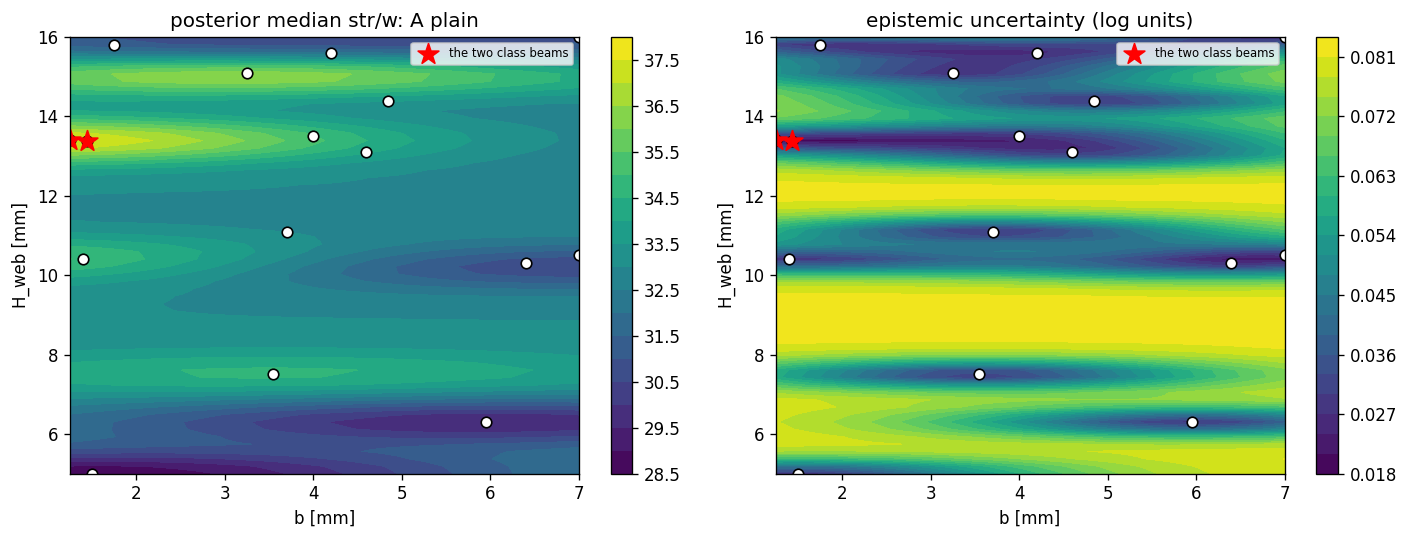

In [4]:
CHOICE = "A plain"      # <<< your lane
NOISE_PCT = 3           # <<< your assumed noise, percent

gpF, fmuF, fsdF, ymF, cfgF = fit_lane(df, CHOICE, alpha=(NOISE_PCT/100)**2)
bg = np.linspace(1.25, 7.0, 60); Hg = np.linspace(5.0, 16.0, 60)
BB, HH = np.meshgrid(bg, Hg)
SWg, SDg = predict_sw(gpF, fmuF, fsdF, ymF, BB.ravel(), HH.ravel(),
                      cfgF["target"], cfgF["feats"])
MU, STD = SWg.reshape(BB.shape), SDg.reshape(BB.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for a, Z, t in [(ax[0], MU, f"posterior median str/w: {CHOICE}"),
                (ax[1], STD, "epistemic uncertainty (log units)")]:
    cf = a.contourf(BB, HH, Z, levels=20); fig.colorbar(cf, ax=a)
    a.scatter(df.b, df.H, c="w", edgecolor="k", s=40)
    a.scatter(df.b.iloc[-2:], df.H.iloc[-2:], c="red", marker="*", s=170,
              label="the two class beams")
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(t); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 4. Choose your beam *(you write this — graded on the memo, not a checkpoint)*

Combine what you have: `MU`, `STD`, the calibrated physics (`capacity`), and
the failure-note table printed above. Standard moves: exploit the posterior
median; use MUI-style exploration; veto
regions the notes make you distrust (which beams peeled apart, and where?).

For orientation only: the *default* recipe — lane A, 3% noise, MUI ψ = 1 —
lands at **(b ≈ 1.25, H_web ≈ 13.20)**. You are free to submit that; you
are also free to beat it. Say why either way.

In [5]:
psi = 1.0                                  # <<< your dial
score = np.log(MU) + psi*STD               # <<< your rule (this is MUI in log space)
i = np.unravel_index(np.argmax(score), score.shape)
b_final, H_final = float(BB[i]), float(HH[i])
print(f"FINAL DESIGN:  b = {b_final:.2f} mm,  H_web = {H_final:.2f} mm")
print(f"  posterior median {MU[i]:.1f} N/g,  epistemic sigma_log {STD[i]:.3f},  "
      f"calibrated physics {capacity(b_final, H_final, SY_CAL, K_CAL, CS_CAL)/estimated_mass_g(b_final, H_final):.1f} N/g")
print(f"  physics mode there: {gov_mode(b_final, H_final, SY_CAL, K_CAL, CS_CAL)}")

FINAL DESIGN:  b = 1.25 mm,  H_web = 13.20 mm
  posterior median 37.0 N/g,  epistemic sigma_log 0.035,  calibrated physics 46.4 N/g
  physics mode there: bend


## Memo

1. The two class beams: use the generated scoreboard percentages, with their
   stated denominators. What does each miss reveal, and which miss is costlier
   for the intended design decision?
2. Your lane: what did the LOO table say, and did you follow it? If you chose
   C or D, what does physics contribute between the observations?
3. Risk: use your printed `psi`, posterior median, epistemic sigma, and final coordinates to explain
   whether you exploited or explored. Is the main risk a weak beam or a model
   that is confidently wrong?
4. Limits: compare your coordinates with the thin-web flange-web-separation
   notes. Where could that unmodeled mechanism affect your design?

The default-parameter design is already computed by the section-4 code. You do
not need a new optimization cell unless you choose a different decision rule.

## KEY: memo targets

1. The scoreboard supplies the actual errors. Overprediction is a capacity-risk
   problem; underprediction is usually a mass/opportunity-cost problem. A strong
   answer distinguishes the denominator instead of comparing ambiguous percentages.
2. Report the generated LOO ordering and at least one beam-level miss. Following
   the lowest RMSE is acceptable but not mandatory if the model-risk argument is
   specific. Physics-informed lanes carry shape outside the data but also inherit
   the empirical interaction model's omissions.
3. The final cell prints all required evidence. Larger `psi` spends more of the
   decision on epistemic uncertainty. The serious risk is confident extrapolation
   into an unmodeled failure region.
4. Flange-web separation occurs in thin-web examples and is absent from the
   yield/LTB equations. Students should locate their design relative to those
   beams rather than claim the mode is impossible.